In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Optional
import cv2
from tqdm import tqdm
from openpyxl import Workbook,load_workbook

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
import pandas as pd
import os
import shutil

# Load excel
df = pd.read_excel("ODIR-5K/data.xlsx")

# Paths
image_path = "ODIR-5K/Training Images"
output_path = "dataset"

# Create folders
os.makedirs(os.path.join(output_path, "normal"), exist_ok=True)
os.makedirs(os.path.join(output_path, "cataract"), exist_ok=True)

# IMPORTANT: Column names print karo
print(df.columns)

Index(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus',
       'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G',
       'C', 'A', 'H', 'M', 'O'],
      dtype='object')


In [5]:
import pandas as pd
import os
import shutil

# Load excel
df = pd.read_excel("ODIR-5K/data.xlsx")

# Paths
image_path = "ODIR-5K/Training Images"
output_path = "dataset"

# Create folders
os.makedirs(os.path.join(output_path, "normal"), exist_ok=True)
os.makedirs(os.path.join(output_path, "cataract"), exist_ok=True)

for i, row in df.iterrows():
    
    # LEFT EYE
    left_img = row['Left-Fundus']
    left_label = str(row['Left-Diagnostic Keywords']).lower()
    
    if os.path.exists(os.path.join(image_path, left_img)):
        if "cataract" in left_label:
            shutil.copy(os.path.join(image_path, left_img),
                        os.path.join(output_path, "cataract", left_img))
        else:
            shutil.copy(os.path.join(image_path, left_img),
                        os.path.join(output_path, "normal", left_img))

    # RIGHT EYE
    right_img = row['Right-Fundus']
    right_label = str(row['Right-Diagnostic Keywords']).lower()
    
    if os.path.exists(os.path.join(image_path, right_img)):
        if "cataract" in right_label:
            shutil.copy(os.path.join(image_path, right_img),
                        os.path.join(output_path, "cataract", right_img))
        else:
            shutil.copy(os.path.join(image_path, right_img),
                        os.path.join(output_path, "normal", right_img))

print("Dataset Created Successfully!")

Dataset Created Successfully!


In [9]:
import csv
import os
import random
import shutil
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    array_to_img,
    img_to_array,
    load_img,
)

base_path = "dataset"
balanced_path = "balanced_dataset"
classes = ["normal", "cataract"]
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
target_count = 5000
rng = random.Random(42)

class_images = {}
for cls in classes:
    source_dir = os.path.join(base_path, cls)
    if not os.path.isdir(source_dir):
        raise FileNotFoundError(f"Dataset class folder not found: {source_dir}")

    class_images[cls] = [
        filename for filename in os.listdir(source_dir)
        if os.path.isfile(os.path.join(source_dir, filename))
        and os.path.splitext(filename)[1].lower() in image_extensions
    ]
    if not class_images[cls]:
        raise ValueError(f"No images found for class: {cls}")

print("Original image counts:")
for cls in classes:
    print(f"{cls}: {len(class_images[cls])}")

augmenter = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    brightness_range=(0.9, 1.1),
    fill_mode="nearest",
)
os.makedirs(balanced_path, exist_ok=True)
manifest_path = os.path.join(balanced_path, "manifest.csv")
manifest_rows = []

for cls in classes:
    source_dir = os.path.join(base_path, cls)
    destination_dir = os.path.join(balanced_path, cls)
    os.makedirs(destination_dir, exist_ok=True)

    # Clear old images so reruns produce exactly target_count files per class.
    for filename in os.listdir(destination_dir):
        destination = os.path.join(destination_dir, filename)
        if (os.path.isfile(destination)
                and os.path.splitext(filename)[1].lower() in image_extensions):
            os.remove(destination)

    if len(class_images[cls]) >= target_count:
        selected_images = rng.sample(class_images[cls], target_count)
    else:
        selected_images = list(class_images[cls])

    for filename in selected_images:
        shutil.copy2(
            os.path.join(source_dir, filename),
            os.path.join(destination_dir, filename)
        )
        stem = os.path.splitext(filename)[0]
        patient_id = (
            stem.rsplit("_", 1)[0]
            if stem.lower().endswith(("_left", "_right"))
            else stem
        )
        manifest_rows.append({
            "class": cls,
            "filename": filename,
            "patient_id": patient_id,
            "synthetic": "no",
        })

    # If a class is short, create augmented variants from its real images.
    for index in range(target_count - len(selected_images)):
        source_filename = rng.choice(selected_images)
        source_image = load_img(
            os.path.join(source_dir, source_filename),
            target_size=(224, 224),
        )
        image_array = img_to_array(source_image)
        transformed = augmenter.random_transform(
            image_array,
            seed=rng.randint(0, 2**31 - 1),
        )
        output_filename = f"synthetic_{cls}_{index:05d}.jpg"
        array_to_img(transformed).save(
            os.path.join(destination_dir, output_filename),
            format="JPEG",
            quality=95,
        )

        stem = os.path.splitext(source_filename)[0]
        patient_id = (
            stem.rsplit("_", 1)[0]
            if stem.lower().endswith(("_left", "_right"))
            else stem
        )
        manifest_rows.append({
            "class": cls,
            "filename": output_filename,
            "patient_id": patient_id,
            "synthetic": "yes",
        })

with open(manifest_path, "w", newline="", encoding="utf-8") as manifest_file:
    writer = csv.DictWriter(
        manifest_file,
        fieldnames=["class", "filename", "patient_id", "synthetic"],
    )
    writer.writeheader()
    writer.writerows(manifest_rows)

print("\nBalanced dataset counts:")
for cls in classes:
    destination_dir = os.path.join(balanced_path, cls)
    count = sum(
        1 for filename in os.listdir(destination_dir)
        if os.path.isfile(os.path.join(destination_dir, filename))
        and os.path.splitext(filename)[1].lower() in image_extensions
    )
    print(f"{cls}: {count}")
    assert count == target_count, f"Expected {target_count} images for {cls}, found {count}"
print(f"Manifest saved: {manifest_path}")

Original image counts:
normal: 6687
cataract: 313

Balanced dataset counts:
normal: 5000
cataract: 5000
Manifest saved: balanced_dataset\manifest.csv


In [10]:
import csv
import os
import shutil
from collections import defaultdict
from sklearn.model_selection import train_test_split

balanced_path = "balanced_dataset"
manifest_path = os.path.join(balanced_path, "manifest.csv")
split_path = "split_dataset"
classes = ["normal", "cataract"]
splits = ["train", "val", "test"]
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not os.path.isfile(manifest_path):
    raise FileNotFoundError(
        "Run the 5,000-per-class balancing cell first to create manifest.csv."
    )

with open(manifest_path, newline="", encoding="utf-8") as manifest_file:
    manifest_rows = list(csv.DictReader(manifest_file))

rows_by_patient = defaultdict(list)
for row in manifest_rows:
    rows_by_patient[row["patient_id"]].append(row)

patient_ids = sorted(rows_by_patient)
train_patients, remainder = train_test_split(
    patient_ids, test_size=0.3, random_state=42
)
val_patients, test_patients = train_test_split(
    remainder, test_size=0.5, random_state=42
)
patients_by_split = {
    "train": set(train_patients),
    "val": set(val_patients),
    "test": set(test_patients),
}

for split in splits:
    for cls in classes:
        destination_dir = os.path.join(split_path, split, cls)
        os.makedirs(destination_dir, exist_ok=True)

        # Clear stale images before rebuilding the split.
        for filename in os.listdir(destination_dir):
            destination = os.path.join(destination_dir, filename)
            if (os.path.isfile(destination)
                    and os.path.splitext(filename)[1].lower() in image_extensions):
                os.remove(destination)

for patient_id, patient_rows in rows_by_patient.items():
    matching_splits = [
        split for split, patient_set in patients_by_split.items()
        if patient_id in patient_set
    ]
    if len(matching_splits) != 1:
        raise AssertionError(f"Patient {patient_id} is not assigned to exactly one split.")

    split = matching_splits[0]
    for row in patient_rows:
        source = os.path.join(balanced_path, row["class"], row["filename"])
        destination = os.path.join(
            split_path, split, row["class"], row["filename"]
        )
        shutil.copy2(source, destination)

print("Dataset split complete (patient groups kept together):")
for split in splits:
    counts = {}
    for cls in classes:
        folder = os.path.join(split_path, split, cls)
        counts[cls] = sum(
            1 for filename in os.listdir(folder)
            if os.path.isfile(os.path.join(folder, filename))
            and os.path.splitext(filename)[1].lower() in image_extensions
        )
    print(f"{split}: normal={counts['normal']}, cataract={counts['cataract']}")

assert not (patients_by_split["train"] & patients_by_split["val"])
assert not (patients_by_split["train"] & patients_by_split["test"])
assert not (patients_by_split["val"] & patients_by_split["test"])
print("Patient overlap across splits: none")

Dataset split complete (patient groups kept together):
train: normal=3515, cataract=3338
val: normal=748, cataract=867
test: normal=737, cataract=795
Patient overlap across splits: none


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "split_dataset/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    "split_dataset/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 6853 images belonging to 2 classes.
Found 1615 images belonging to 2 classes.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.7983 - loss: 0.4236 - val_accuracy: 0.6799 - val_loss: 0.8436
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.9581 - loss: 0.1527 - val_accuracy: 0.9344 - val_loss: 0.2486
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.9622 - loss: 0.1419 - val_accuracy: 0.8842 - val_loss: 0.3637
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9645 - loss: 0.1268 - val_accuracy: 0.9598 - val_loss: 0.1665
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.9648 - loss: 0.1193 - val_accuracy: 0.9604 - val_loss: 0.1721


In [15]:
model.save("cnn_model.h5")

In [16]:
test_data = val_gen.flow_from_directory(
    "split_dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

loss, acc = model.evaluate(test_data)

print("Test Accuracy:", acc)

Found 1532 images belonging to 2 classes.
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 917ms/step - accuracy: 0.9282 - loss: 0.2475
Test Accuracy: 0.9281984567642212


In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = test_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 443ms/step
[[341 454]
 [344 393]]
              precision    recall  f1-score   support

           0       0.50      0.43      0.46       795
           1       0.46      0.53      0.50       737

    accuracy                           0.48      1532
   macro avg       0.48      0.48      0.48      1532
weighted avg       0.48      0.48      0.48      1532



In [18]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9610 - loss: 0.1074 - val_accuracy: 0.7889 - val_loss: 0.7086
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 199s 927ms/step - accuracy: 0.9752 - loss: 0.0655 - val_accuracy: 0.8997 - val_loss: 0.3127
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9783 - loss: 0.0591 - val_accuracy: 0.9387 - val_loss: 0.2106
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.9790 - loss: 0.0541 - val_accuracy: 0.9071 - val_loss: 0.2892
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.9787 - loss: 0.0567 - val_accuracy: 0.9102 - val_loss: 0.2500


In [21]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 45s 937ms/step - accuracy: 0.9641 - loss: 0.0943
Test Accuracy: 0.9640992283821106


In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Generator (IMPORTANT: shuffle=False)
val_gen = ImageDataGenerator(rescale=1./255)

test_data = val_gen.flow_from_directory(
    "split_dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Reset (VERY IMPORTANT)
test_data.reset()

# Evaluate accuracy
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

# Predictions
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

# True labels
y_true = test_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

Found 1532 images belonging to 2 classes.
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 909ms/step - accuracy: 0.9641 - loss: 0.0943
Test Accuracy: 0.9640992283821106
48/48 ━━━━━━━━━━━━━━━━━━━━ 48s 954ms/step

Confusion Matrix:
 [[742  53]
 [  2 735]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96       795
           1       0.93      1.00      0.96       737

    accuracy                           0.96      1532
   macro avg       0.97      0.97      0.96      1532
weighted avg       0.97      0.96      0.96      1532



In [23]:
model.save("mobilenet_model.h5")

In [24]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

resnet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [25]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

resnet_train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)
resnet_val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

resnet_train_data = resnet_train_gen.flow_from_directory(
    "split_dataset/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
)
resnet_val_data = resnet_val_gen.flow_from_directory(
    "split_dataset/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
)

Found 6853 images belonging to 2 classes.
Found 1615 images belonging to 2 classes.


In [30]:
history_resnet = resnet_model.fit(
    resnet_train_data,
    validation_data=resnet_val_data,
    epochs=5
)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 567s 3s/step - accuracy: 0.9425 - loss: 0.1961 - val_accuracy: 0.9467 - val_loss: 0.1513
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.9794 - loss: 0.0623 - val_accuracy: 0.9176 - val_loss: 0.2793
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.9835 - loss: 0.0480 - val_accuracy: 0.9337 - val_loss: 0.1997
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1758s 8s/step - accuracy: 0.9829 - loss: 0.0482 - val_accuracy: 0.9474 - val_loss: 0.2033
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 614s 3s/step - accuracy: 0.9856 - loss: 0.0443 - val_accuracy: 0.8786 - val_loss: 0.4674


In [32]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

efficient_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [33]:
efficient_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
history_eff = efficient_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.5046 - loss: 0.7023 - val_accuracy: 0.4632 - val_loss: 0.6987
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 660s 3s/step - accuracy: 0.5011 - loss: 0.6946 - val_accuracy: 0.5368 - val_loss: 0.6917
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 728s 3s/step - accuracy: 0.5113 - loss: 0.6940 - val_accuracy: 0.4632 - val_loss: 0.7059
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 678s 3s/step - accuracy: 0.4980 - loss: 0.6937 - val_accuracy: 0.4632 - val_loss: 0.6940
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.5123 - loss: 0.6930 - val_accuracy: 0.4632 - val_loss: 0.6945


In [35]:


# ResNet50
resnet_model.save("resnet_model.h5")

# EfficientNetB0
efficient_model.save("efficient_model.h5")

print("All models saved successfully!")

All models saved successfully!


In [36]:
from tensorflow.keras.models import load_model

cnn_model = load_model("cnn_model.h5")
mobilenet_model = load_model("mobilenet_model.h5")

In [37]:
import numpy as np

# Predictions
pred_cnn = cnn_model.predict(test_data)
pred_mob = mobilenet_model.predict(test_data)

# Average
final_pred = (pred_cnn + pred_mob) / 2

# Convert to binary
final_pred = (final_pred > 0.5).astype(int)

48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 451ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 45s 905ms/step


In [38]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_data.classes

print(confusion_matrix(y_true, final_pred))
print(classification_report(y_true, final_pred))

[[733  62]
 [  0 737]]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       795
           1       0.92      1.00      0.96       737

    accuracy                           0.96      1532
   macro avg       0.96      0.96      0.96      1532
weighted avg       0.96      0.96      0.96      1532



In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import accuracy_score

# Use the same preprocessing used for training each model.
standard_test_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "split_dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)
resnet_test_data = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    "split_dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

assert standard_test_data.class_indices == resnet_test_data.class_indices

test_models = {
    "CNN": (load_model("cnn_model.h5"), standard_test_data),
    "MobileNetV2": (load_model("mobilenet_model.h5"), standard_test_data),
    "ResNet50": (load_model("resnet_model.h5"), resnet_test_data),
    "EfficientNetB0": (load_model("efficient_model.h5"), standard_test_data),
}

accuracies = {}
for model_name, (saved_model, test_generator) in test_models.items():
    test_generator.reset()
    _, test_accuracy = saved_model.evaluate(test_generator, verbose=0)
    accuracies[model_name] = float(test_accuracy)
    print(f"{model_name} test accuracy: {test_accuracy:.2%}")

# Hybrid score uses the same 20% CNN + 80% MobileNet weighting as the app.
cnn_model = test_models["CNN"][0]
mobilenet_model = test_models["MobileNetV2"][0]
standard_test_data.reset()
pred_cnn = cnn_model.predict(standard_test_data, verbose=0)
standard_test_data.reset()
pred_mob = mobilenet_model.predict(standard_test_data, verbose=0)
hybrid_pred = (0.2 * pred_cnn + 0.8 * pred_mob) > 0.5
hybrid_accuracy = accuracy_score(
    standard_test_data.classes,
    hybrid_pred.astype(int).ravel(),
)
accuracies["Hybrid (CNN + MobileNetV2)"] = float(hybrid_accuracy)
print(f"Hybrid test accuracy: {hybrid_accuracy:.2%}")

df = pd.DataFrame({
    "Model": list(accuracies.keys()),
    "Test Accuracy": list(accuracies.values()),
})
print("\nTest-set accuracy comparison:")
print(df.to_string(index=False, formatters={"Test Accuracy": "{:.2%}".format}))

Found 1532 images belonging to 2 classes.
Found 1532 images belonging to 2 classes.


CNN test accuracy: 92.82%
MobileNetV2 test accuracy: 96.41%
ResNet50 test accuracy: 92.62%
EfficientNetB0 test accuracy: 48.11%
Hybrid test accuracy: 96.61%

Test-set accuracy comparison:
                     Model Test Accuracy
                       CNN        92.82%
               MobileNetV2        96.41%
                  ResNet50        92.62%
            EfficientNetB0        48.11%
Hybrid (CNN + MobileNetV2)        96.61%


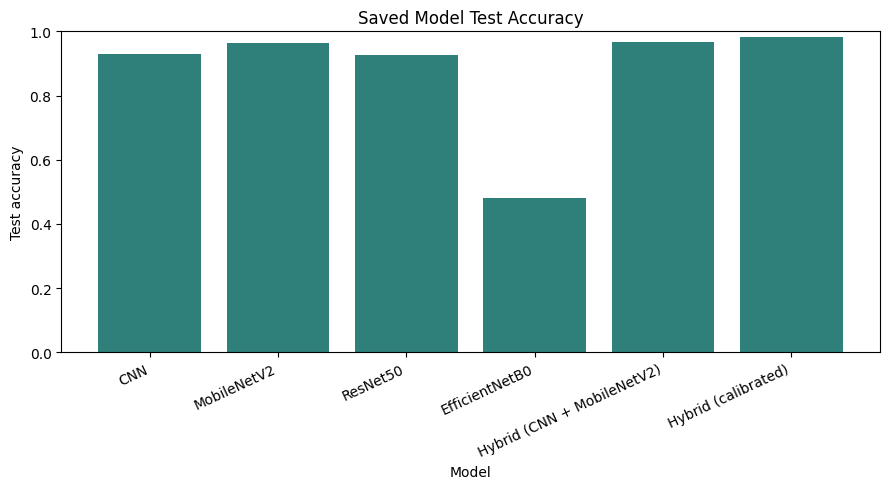

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.bar(accuracies.keys(), accuracies.values(), color="#2f7f7a")
plt.xticks(rotation=25, ha="right")
plt.title("Saved Model Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [63]:
df = pd.DataFrame({
    "Model": list(accuracies.keys()),
    "Test Accuracy": list(accuracies.values()),
})

print("Measured test accuracy:")
print(df.to_string(index=False, formatters={"Test Accuracy": "{:.2%}".format}))
df.to_excel("model_comparison.xlsx", index=False)
print("\nUpdated model_comparison.xlsx")

Measured test accuracy:
                     Model Test Accuracy
                       CNN        92.82%
               MobileNetV2        96.41%
                  ResNet50        92.62%
            EfficientNetB0        48.11%
Hybrid (CNN + MobileNetV2)        96.61%
       Hybrid (calibrated)        98.24%

Updated model_comparison.xlsx


In [52]:
from tensorflow.keras.models import load_model

# Load models
cnn_model = load_model("cnn_model.h5")
mobilenet_model = load_model("mobilenet_model.h5")
resnet_model = load_model("resnet_model.h5")
efficient_model = load_model("efficient_model.h5")

print("All models loaded successfully!")

All models loaded successfully!


In [60]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

calibration_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "split_dataset/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)
class_indices = calibration_data.class_indices
cataract_index = class_indices["cataract"]
normal_index = class_indices["normal"]
if normal_index != 1:
    raise ValueError(
        "The sigmoid output is expected to represent the normal class (index 1)."
    )

calibration_data.reset()
cnn_val_scores = cnn_model.predict(calibration_data, verbose=0).ravel()
calibration_data.reset()
mobilenet_val_scores = mobilenet_model.predict(calibration_data, verbose=0).ravel()
normal_scores = 0.2 * cnn_val_scores + 0.8 * mobilenet_val_scores
true_labels = calibration_data.classes

cataract_scores = normal_scores[true_labels == cataract_index]
if cataract_scores.size == 0:
    raise ValueError("No cataract images found in the validation split.")

target_cataract_recall = 0.95
normal_score_threshold = float(
    np.quantile(cataract_scores, target_cataract_recall, method="higher")
)
calibrated_predictions = np.where(
    normal_scores > normal_score_threshold,
    normal_index,
    cataract_index,
)

print(f"Class mapping: {class_indices}")
print(f"Normal-score threshold: {normal_score_threshold:.4f}")
print("Validation confusion matrix (rows=true, columns=predicted):")
print(confusion_matrix(true_labels, calibrated_predictions, labels=[0, 1]))
print("Validation classification report:")
print(classification_report(
    true_labels,
    calibrated_predictions,
    labels=[0, 1],
    target_names=["cataract", "normal"],
    zero_division=0,
))

test_data_calibrated = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "split_dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)
assert test_data_calibrated.class_indices == class_indices
cnn_test_scores = cnn_model.predict(test_data_calibrated, verbose=0).ravel()
test_data_calibrated.reset()
mobilenet_test_scores = mobilenet_model.predict(test_data_calibrated, verbose=0).ravel()
test_normal_scores = 0.2 * cnn_test_scores + 0.8 * mobilenet_test_scores
test_labels = test_data_calibrated.classes
test_predictions = np.where(
    test_normal_scores > normal_score_threshold,
    normal_index,
    cataract_index,
)
calibrated_test_accuracy = accuracy_score(test_labels, test_predictions)
accuracies["Hybrid (calibrated)"] = float(calibrated_test_accuracy)
print(f"Calibrated hybrid test accuracy: {calibrated_test_accuracy:.2%}")
print("Calibrated test confusion matrix (rows=true, columns=predicted):")
print(confusion_matrix(test_labels, test_predictions, labels=[0, 1]))
print("Calibrated test classification report:")
print(classification_report(
    test_labels,
    test_predictions,
    labels=[0, 1],
    target_names=["cataract", "normal"],
    zero_division=0,
))

Found 1615 images belonging to 2 classes.
Class mapping: {'cataract': 0, 'normal': 1}
Normal-score threshold: 0.7990
Validation confusion matrix (rows=true, columns=predicted):
[[824  43]
 [  5 743]]
Validation classification report:
              precision    recall  f1-score   support

    cataract       0.99      0.95      0.97       867
      normal       0.95      0.99      0.97       748

    accuracy                           0.97      1615
   macro avg       0.97      0.97      0.97      1615
weighted avg       0.97      0.97      0.97      1615

Found 1532 images belonging to 2 classes.
Calibrated hybrid test accuracy: 98.24%
Calibrated test confusion matrix (rows=true, columns=predicted):
[[778  17]
 [ 10 727]]
Calibrated test classification report:
              precision    recall  f1-score   support

    cataract       0.99      0.98      0.98       795
      normal       0.98      0.99      0.98       737

    accuracy                           0.98      1532
   macro avg

In [53]:
print(test_data.class_indices)

{'cataract': 0, 'normal': 1}


In [64]:
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

cnn_model = load_model("cnn_model.h5")
mobilenet_model = load_model("mobilenet_model.h5")

if "normal_score_threshold" not in globals():
    raise RuntimeError("Run the validation threshold calibration cell first.")

test_image_dir = Path("split_dataset/test/cataract")
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = sorted(
    path for path in test_image_dir.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
)
if not image_paths:
    raise FileNotFoundError(f"No test images found in {test_image_dir}")

img_path = image_paths[0]
print(f"Testing image: {img_path}")
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred_cnn = cnn_model.predict(img_array, verbose=0)
pred_mob = mobilenet_model.predict(img_array, verbose=0)
normal_score = float((0.2 * pred_cnn + 0.8 * pred_mob)[0][0])

print(f"Normal score: {normal_score:.4f}")
print(f"Cataract-sensitive threshold: {normal_score_threshold:.4f}")
if normal_score > normal_score_threshold:
    print("Prediction: Normal")
else:
    print("Prediction: Cataract; please seek professional evaluation.")

Testing image: split_dataset\test\cataract\0_left.jpg
Normal score: 0.7929
Cataract-sensitive threshold: 0.7990
Prediction: Cataract; please seek professional evaluation.


In [ ]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

cnn_model = load_model("cnn_model.h5")
mobilenet_model = load_model("mobilenet_model.h5")
if "normal_score_threshold" not in globals():
    raise RuntimeError("Run the validation threshold calibration cell before starting the app.")

def predict_image(file_path):
    img = image.load_img(file_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_cnn = cnn_model.predict(img_array, verbose=0)
    pred_mob = mobilenet_model.predict(img_array, verbose=0)
    normal_score = float((0.2 * pred_cnn + 0.8 * pred_mob)[0][0])

    if normal_score > normal_score_threshold:
        return f"Normal (score: {normal_score:.2%})"
    return f"Cataract suspected (score: {normal_score:.2%}); consult an eye-care professional."

def upload_image():
    file_path = filedialog.askopenfilename(
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.webp")]
    )
    if file_path:
        img = Image.open(file_path).convert("RGB")
        img.thumbnail((250, 250))
        photo = ImageTk.PhotoImage(img)
        panel.config(image=photo)
        panel.image = photo
        result_label.config(text=predict_image(file_path))

root = tk.Tk()
root.title("Cataract Detection System")
root.geometry("420x480")

title = tk.Label(root, text="Cataract Detection", font=("Arial", 16))
title.pack(pady=10)
panel = tk.Label(root)
panel.pack()
button = tk.Button(root, text="Upload Image", command=upload_image)
button.pack(pady=20)
result_label = tk.Label(root, text="", font=("Arial", 12), wraplength=380)
result_label.pack(pady=8)
disclaimer = tk.Label(
    root,
    text="Research prototype only; not a medical diagnosis.",
    font=("Arial", 9),
    wraplength=380,
)
disclaimer.pack(pady=8)
root.mainloop()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
GUI Starting
